# Modelo Novo-Keynesiano (Calvo) em SSJ — equações em nível

Réplica do modelo NK de Celso Costa (*Understanding DSGE Models*), com as
equações **em nível, pós-Lagrangiano, sem log-linearizar** — o SSJ lineariza
numericamente em torno do estado estacionário.

### Como tratamos o somatório infinito do preço ótimo
A equação $P_t^*=\frac{\psi}{\psi-1}E_t\sum_{i=0}^\infty(\beta\theta)^i MC_{t+i}$
nunca é implementada como soma truncada. Define-se a soma como variável
auxiliar com **uma recursão de um período à frente**:
$$S_t = MC_t + \beta\theta\,E_tS_{t+1},\qquad P_t^*=\tfrac{\psi}{\psi-1}S_t.$$
Como $S_t,MC_t$ são nominais, dividimos por $P_t$ e trabalhamos com o custo
marginal real $mc_t=MC_t/P_t$, o preço relativo de reset $x_t=P_t^*/P_t$ e a
inflação $\pi_t$ — tudo estacionário, ainda em nível:
$$G_t = mc_t + \beta\theta\,E_t[\pi_{t+1}G_{t+1}],\qquad x_t=\tfrac{\psi}{\psi-1}G_t.$$
O nível de preços $P_t$ some (o sistema é homogêneo de grau 1 nos nominais);
acompanhamos a inflação no lugar dele.

### Fechamento monetário (necessário)
As 12 equações da tabela, sozinhas, são **indeterminadas**: a eq. de custo
marginal é implicada por produção + demandas de fatores, e nada fixa o custo
marginal real / o markup. Falta uma âncora nominal. Adicionamos o fechamento
padrão mínimo — Euler do título nominal (define $i_t$) + regra de Taylor (fixa
$\pi$). É o bloco `monetary`/`taylor` abaixo; troque pela regra do livro se quiser.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sequence_jacobian import simple, create_model

## 1. Blocos do modelo

`K(-1)` é o capital que entra na produção do período (convenção fim-de-período,
estado predeterminado). `mc`, `rr=R/P` e `w=W/P` são reais.

In [2]:
@simple
def calvo(pi, beta, theta, psi):
    # agregador de Calvo (eq. nivel de precos), em forma de razao:
    x  = ((1 - theta*pi**(psi-1))/(1 - theta))**(1/(1-psi))   # x = P*/P
    Gp = x*(psi-1)/psi                                        # x = (psi/(psi-1)) Gp
    mc = Gp - beta*theta*pi(+1)*Gp(+1)                        # recursao do somatorio
    return x, Gp, mc

@simple
def firm(K, L, A, mc, alpha):
    Y  = A * K(-1)**alpha * L**(1-alpha)      # producao
    rr = alpha   * mc * Y / K(-1)             # demanda por capital  -> aluguel real
    w  = (1-alpha)* mc * Y / L                # demanda por trabalho -> salario real
    return Y, rr, w

@simple
def capital(K, delta):
    I = K - (1-delta)*K(-1)                   # lei de movimento do capital
    return I

@simple
def monetary(C, pi, beta, sigma):
    # Euler do titulo nominal: 1 = beta(1+i)E[(C'/C)^-sigma / pi']  -> define i
    i = 1/(beta*(C(+1)/C)**(-sigma)/pi(+1)) - 1
    return i

@simple
def equilibrium(C, L, w, rr, Y, I, pi, i, beta, sigma, delta, phi, phi_pi):
    labor  = C**sigma * L**phi - w                                  # oferta de trabalho
    euler  = (C(+1)/C)**sigma - beta*((1-delta) + rr(+1))           # Euler do capital
    goods  = Y - C - I                                              # equilibrio de bens
    taylor = i - ((1/beta - 1) + phi_pi*(pi - 1))                   # regra de Taylor
    return labor, euler, goods, taylor

## 2. Montagem do modelo

In [3]:
NK = create_model([calvo, firm, capital, monetary, equilibrium], name="NK")

print(NK)
print(f"Blocks: {NK.blocks}")

<Model 'NK'>
Blocks: [<SimpleBlock 'monetary'>, <SimpleBlock 'capital'>, <SimpleBlock 'calvo'>, <SimpleBlock 'firm'>, <SimpleBlock 'equilibrium'>]


## 3. Incógnitas, alvos e choque

Quatro `unknowns` para quatro `targets`. As outras variáveis ($Y,mc,w,rr,x,G,i,I$)
são computadas para frente nos blocos. A regra de Taylor é o quarto alvo que
ancora a inflação — sem ela o sistema fica indeterminado.

In [4]:
unknowns = ['C', 'K', 'L', 'pi']
targets  = ['labor', 'euler', 'goods', 'taylor']
inputs   = ['A']

## 4. Estado estacionário

In [5]:
calibration = {"A": 1., "pi": 1., "sigma": 2.0, "phi": 1.5, "beta": 0.985,
               "delta": 0.025, "alpha": 0.35, "psi": 8., "theta": 0.75, "phi_pi": 1.5}
unknowns_ss = {"C": 0.739, "K": 1.547, "L": 0.537}
targets_ss  = {"labor": 0., "euler": 0., "goods": 0.}   # pi=1 fixo na calibracao

In [6]:
ss = NK.solve_steady_state(calibration, unknowns_ss, targets_ss, solver="hybr")

for k in ["C", "K", "L", "Y", "I", "mc", "w", "rr", "x", "pi", "i"]:
    print(f"  {k:>3s} = {ss[k]:.5f}")
print(f"\n  markup bruto = {1/ss['mc']:.3f}   (psi/(psi-1) = {8/7:.3f})")

    C = 0.73922
    K = 1.54712
    L = 0.53721
    Y = 0.77790
    I = 0.03868
   mc = 0.22859
    w = 0.21516
   rr = 0.04023
    x = 1.00000
   pi = 1.00000
    i = 0.01523

  markup bruto = 4.375   (psi/(psi-1) = 1.143)


O markup de estado estacionário sai alto porque a eq. 8 da tabela não traz o
fator de normalização $(1-\beta\theta)$. Se quiser o markup "limpo"
$\psi/(\psi-1)$, multiplique o termo `mc` da recursão por $1/(1-\beta\theta)$.

## 5. Jacobiano de equilíbrio geral

In [7]:
G = NK.solve_jacobian(ss, unknowns, targets, inputs, T=300)
print(G)

<JacobianDict outputs=['C', 'K', 'L', 'pi', 'x', 'Gp', 'mc', 'Y', 'rr', 'w', 'I', 'i', 'labor', 'euler', 'goods', 'taylor'], inputs=['A']>


## 6. Choque de produtividade AR(1) e IRFs

In [8]:
T, impact, rho = 300, 0.01, 0.95
dA = impact * rho**np.arange(T)            # IRF de um AR(1): 1, rho, rho^2, ...

In [9]:
varlist = [("A","Productivity","brown"), ("Y","Output","green"),
           ("C","Consumption","blue"), ("I","Investment","cyan"),
           ("L","Labor","red"), ("K","Capital","black"),
           ("w","Real wage","purple"), ("rr","Real rental","orange"),
           ("mc","Marginal cost","grey"), ("pi","Inflation","magenta"),
           ("i","Nominal rate","teal")]

irf = {"A": 100 * dA / ss["A"]}               # o choque (input exogeno)
for v, _, _ in varlist:
    if v == "A":
        continue
    irf[v] = 100 * (G[v]["A"] @ dA) / ss[v]   # % de desvio do ss

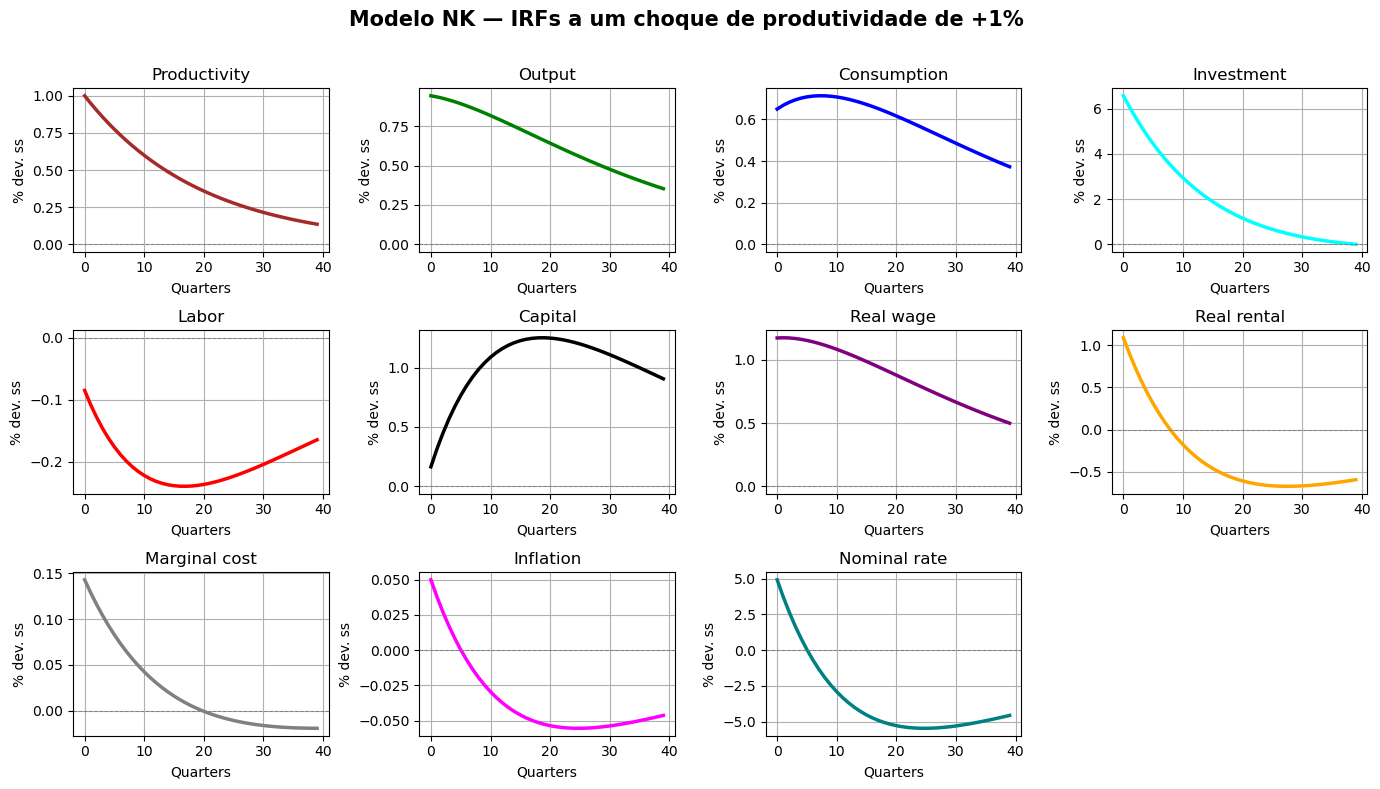

In [11]:
fig, axs = plt.subplots(3, 4, figsize=(14, 8))
for ax, (v, title, color) in zip(axs.flatten(), varlist):
    ax.plot(irf[v][:40], lw=2.5, color=color)
    ax.axhline(0, color="grey", lw=0.7, ls="--")
    ax.set_title(title); ax.set_xlabel("Quarters"); ax.set_ylabel("% dev. ss")
    ax.grid()
for ax in axs.flatten()[len(varlist):]:
    ax.axis("off")
fig.suptitle("Modelo NK — IRFs a um choque de produtividade de +1%", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()